
# Intervalos de confianza

Un **intervalo de confianza (IC)** es un rango de valores que, con cierta probabilidad (ej. 95%), contiene el valor verdadero de un parámetro poblacional.

Depende de:
- El estimador (media, proporción, etc.)
- La variabilidad de los datos
- El tamaño de la muestra
- El nivel de confianza (1 - alfa)


In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

## 1. Intervalo de confianza para la media (σ conocida)

#### Ejemplo teórico

In [2]:
n = 36
media = 2.6
sigma = 0.3

z_95 = st.norm.ppf(1 - 0.05/2)
z_99 = st.norm.ppf(1 - 0.01/2)

ic95 = (media - z_95*sigma/np.sqrt(n), media + z_95*sigma/np.sqrt(n))
ic99 = (media - z_99*sigma/np.sqrt(n), media + z_99*sigma/np.sqrt(n))

print("IC 95%:", ic95)
print("IC 99%:", ic99)

IC 95%: (2.502001800772997, 2.697998199227003)
IC 99%: (2.471208534822555, 2.728791465177445)


#### Simulación

In [3]:
np.random.seed(42)  # para reproducibilidad

In [4]:
# Simulamos una población normal

sigma = 10  # desviación poblacional conocida
poblacion = np.random.normal(loc=50, scale=sigma, size=10000)
media_real = np.mean(poblacion)

IC 95% para la media (σ conocida): (46.88153152558735, 54.03830810045598)


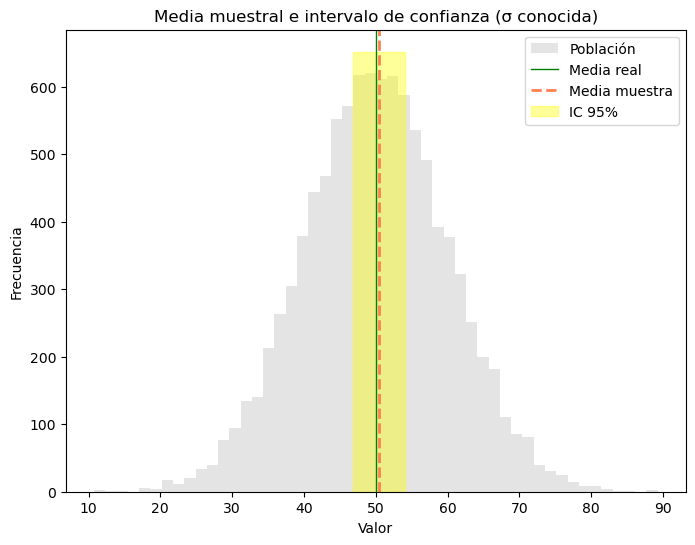

In [5]:
# tomamos una muestra y calculamos un IC con nivel de confianza 95 %

n = 30      # tamaño muestral
muestra = np.random.choice(poblacion, size=n)
media_muestra = np.mean(muestra)
muestra

alfa = 0.05
z = st.norm.ppf(1 - alfa/2)

ic_inf = media_muestra - z * sigma/np.sqrt(n)
ic_sup = media_muestra + z * sigma/np.sqrt(n)

print("IC 95% para la media (σ conocida):", (ic_inf, ic_sup))

# gráfico
plt.figure(figsize=(8,6))
plt.hist(poblacion, bins=50, color='lightgrey', alpha=0.6, label='Población')
plt.axvline(media_real, color='green', linestyle='-', linewidth=1, label='Media real')
plt.axvline(media_muestra, color='coral', linestyle='--', linewidth=2, label='Media muestra')
plt.fill_betweenx(y=[0, plt.gca().get_ylim()[1]], x1=ic_inf, x2=ic_sup, color='yellow', alpha=0.4, label='IC 95%')
plt.title('Media muestral e intervalo de confianza (σ conocida)', fontsize=12)
plt.xlabel('Valor', fontsize=10)
plt.ylabel('Frecuencia', fontsize=10)
plt.legend(fontsize=10)
plt.show()


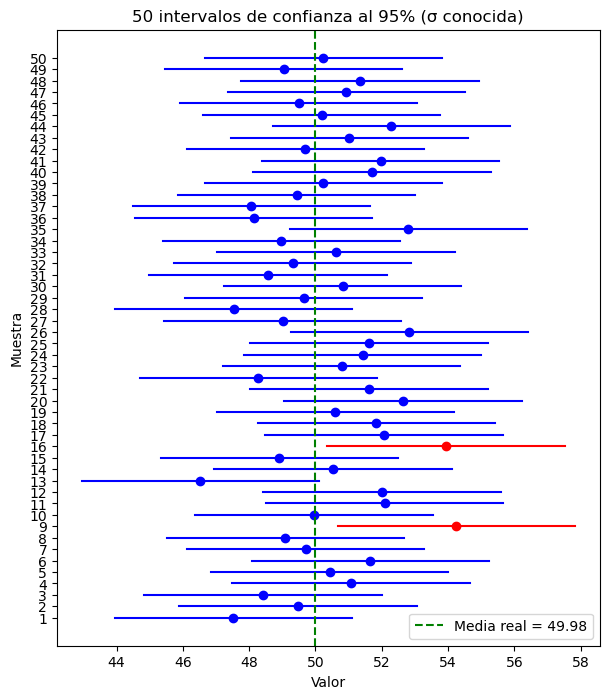

In [6]:
# calculamos 50 intervalos de confianza

alfa = 0.05
z = st.norm.ppf(1 - alfa/2)

medias = []
intervalos = []
contiene = []  # True si el IC contiene la media real

for i in range(50):
    muestra = np.random.choice(poblacion, size=n, replace=False)
    media_m = np.mean(muestra)
    
    ic_inf = media_m - z * sigma / np.sqrt(n)
    ic_sup = media_m + z * sigma / np.sqrt(n)
    
    medias.append(media_m)
    intervalos.append((ic_inf, ic_sup))
    contiene.append(ic_inf <= media_real <= ic_sup)


# Graficamos
plt.figure(figsize=(7,8))

for i, (ic, m, ok) in enumerate(zip(intervalos, medias, contiene)):
    color = "blue" if ok else "red"  # rojo si NO contiene la media real
    plt.plot([ic[0], ic[1]], [i, i], color=color)
    plt.plot(m, i, "o", color=color)

# Línea de la media real
plt.axvline(media_real, color="green", linestyle="--", label=f"Media real = {media_real:.2f}")

plt.yticks(range(len(intervalos)), range(1, len(intervalos)+1))
plt.xlabel("Valor")
plt.ylabel("Muestra")
plt.title("50 intervalos de confianza al 95% (σ conocida)")
plt.legend()
plt.show()


## 2. Intervalo de confianza para la media (σ desconocida, t-Student)

In [7]:
# tomamos una muestra chica

n = 10      # tamaño muestral
muestra = np.random.choice(poblacion, size=n)

media_muestra = np.mean(muestra)
s = np.std(muestra, ddof=1)

print(muestra)
print(f'\nMedia muestral: {media_muestra:.2f}\nDesviación muestral:{s:.4f}')

[47.84332362 61.59839966 40.21627222 59.33810426 53.60226037 52.11396567
 39.43442357 45.52038662 55.57137618 61.20685706]

Media muestral: 51.64
Desviación muestral:8.1706


In [8]:
# calculamos un IC con nivel de confianza 95 %
# Usamos distribución t
ic_t = st.t.interval(confidence=0.95, df=n-1, loc=media_muestra, scale=s/np.sqrt(n))
print("IC 95% para la media (σ desconocida):", ic_t)

IC 95% para la media (σ desconocida): (45.79964353208732, 57.489430318841904)


## 3. Intervalo de confianza unilateral superior (σ conocida)

In [9]:
n = 25
media = 6.2
sigma = 2.0   # desviación estándar; raíz de varianza=4
z_95 = st.norm.ppf(0.95)

ic_sup = ( -np.inf, media + z_95 * sigma/np.sqrt(n))
print("IC 95% unilateral superior:", ic_sup)

IC 95% unilateral superior: (-inf, 6.857941450780589)


## 4. Intervalo para diferencia de medias (σ conocidas)

Se llevó a cabo un experimento donde se compararon dos tipos de motores, A y B. Se midió el rendimiento de combustible en litros cada 100 km.
Se realizaron 50 mediciones con el motor tipo A y 75 con el motor de tipo B.
La gasolina utilizada y las demás condiciones se mantuvieron constantes.

El consumo promedio fue de aproximadamente 5,6 litros / 100 km. para el motor A y   6,5 litros / 100 km para el motor B.

Calcular un intervalo de confianza del 96 % sobre µB - µA, donde µA y µB corresponden a los consumos medios de los motores A y B respectivamente.
Suponer que las desviaciones estándar son 1,07 litros / 100 km. para A y 0,9 litros / 100 km. para B.

In [10]:
# Ejemplo: Motores A y B
n1, n2 = 50, 75
media1, media2 = 5.6, 6.5
sigma1, sigma2 = 1.07, 0.9
diferencia = media2 - media1
print(f"Diferencia de medias: {diferencia}")

Diferencia de medias: 0.9000000000000004


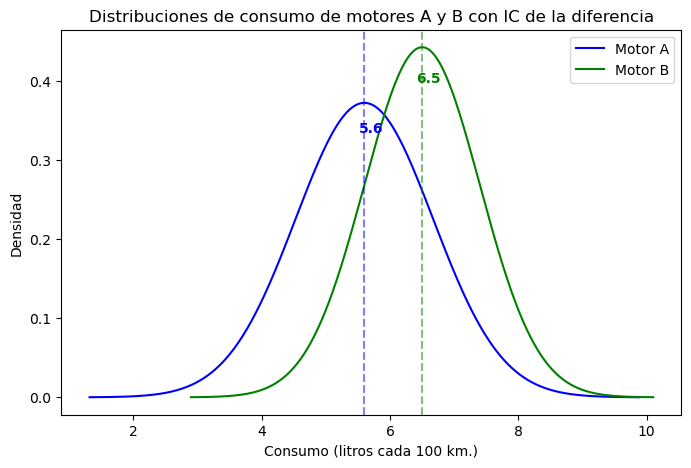

In [11]:
# Valores para las distribuciones
x1 = np.linspace(media1 - 4*sigma1, media1 + 4*sigma1, 500)
x2 = np.linspace(media2 - 4*sigma2, media2 + 4*sigma2, 500)

# Distribuciones normales
y1 = st.norm.pdf(x1, media1, sigma1) # función de densidad de probabilidad de x1
y2 = st.norm.pdf(x2, media2, sigma2) # función de densidad de probabilidad de x2

# Graficar PDFs
plt.figure(figsize=(8,5))
plt.plot(x1, y1, label='Motor A', color='blue')
plt.plot(x2, y2, label='Motor B', color='green')

# Líneas verticales para las medias
plt.axvline(media1, color='blue', linestyle='--', alpha=0.5)
plt.axvline(media2, color='green', linestyle='--', alpha=0.5)
plt.text(media1+0.1, max(y1)*0.9, f'{media1}', color='blue', ha='center', fontweight='bold')
plt.text(media2+0.1, max(y2)*0.9, f'{media2}', color='green', ha='center', fontweight='bold')


plt.xlabel("Consumo (litros cada 100 km.)")
plt.ylabel("Densidad")
plt.title("Distribuciones de consumo de motores A y B con IC de la diferencia")
plt.legend()
plt.show()

In [12]:
# Calcula el IC para la diferencia de medias
alpha = 0.04   # 96% de confianza
z = st.norm.ppf(1 - alpha/2)
error = z * np.sqrt(sigma1**2/n1 + sigma2**2/n2)
ci_lower, ci_upper = (diferencia - error, diferencia + error)
print(f"IC 96% para µB - µA: ({ci_lower:.4f}, {ci_upper:.4f})")

IC 96% para µB - µA: (0.5230, 1.2770)


## 5. Intervalo para la varianza

Los siguientes son los pesos, en decagramos, de 10 paquetes de semillas de pasto distribuidas por cierta empresa: 46,4; 46,1; 45,8; 47,0; 46,1; 45,9; 45,8; 46,9; 45,2 y 46,0.

Calcular un intervalo de confianza del 95 % para la varianza de todos los pesos de este tipo de paquetes de semillas de pasto distribuidos por la empresa. Suponga una población normal.

In [13]:
datos = np.array([46.4, 46.1, 45.8, 47.0, 46.1, 45.9, 45.8, 46.9, 45.2, 46.0])
n = len(datos)
s2 = np.var(datos, ddof=1)

alpha = 0.05
chi2_inf = st.chi2.ppf(1 - alpha/2, df=n-1)
chi2_sup = st.chi2.ppf(alpha/2, df=n-1)

ic_var = ((n-1)*s2/chi2_inf, (n-1)*s2/chi2_sup)
print("IC 95% para σ²:", ic_var)

IC 95% para σ²: (0.13541667686149972, 0.9539364599139246)


## 6. Intervalo para cociente de varianzas

In [14]:
# Ejemplo con dos muestras artificiales
muestra1 = np.random.normal(10, 3, size=50)
muestra2 = np.random.normal(10, 2, size=50)

s1, s2 = np.var(muestra1, ddof=1), np.var(muestra2, ddof=1)
n1, n2 = len(muestra1), len(muestra2)

f_inf = st.f.ppf(alpha/2, dfn=n1-1, dfd=n2-1)
f_sup = st.f.ppf(1 - alpha/2, dfn=n1-1, dfd=n2-1)

cociente = s1/s2
ic_cociente = (cociente/f_sup, cociente/f_inf)

print("IC 95% para σ1²/σ2²:", ic_cociente)

IC 95% para σ1²/σ2²: (0.7842911224729773, 2.4354658371245206)


## 7. Intervalo para la media con bootstrap

El bootstrap construye el intervalo a partir de la variabilidad real de los datos, sin necesidad de suponer normalidad.

In [15]:
# Muestra pequeña sin distribución conocida
muestra = np.array([25, 28, 30, 32, 35, 36, 40, 42, 45, 50])
media_muestral = np.mean(muestra)

# Parámetros
n = len(muestra)
n_bootstrap = 10000  # número de remuestras

# Generamos remuestras bootstrap y calculamos la media en cada una
medias_bootstrap = np.array([np.mean(np.random.choice(muestra, size=n, replace=True)) 
                             for _ in range(n_bootstrap)])

# Intervalo de confianza bootstrap (percentil 2.5% y 97.5%)
ic_inf, ic_sup = np.percentile(medias_bootstrap, [2.5, 97.5])

print(f"IC 95% con Bootstrap ({ic_inf}, {ic_sup})")

IC 95% con Bootstrap (31.7, 41.0)


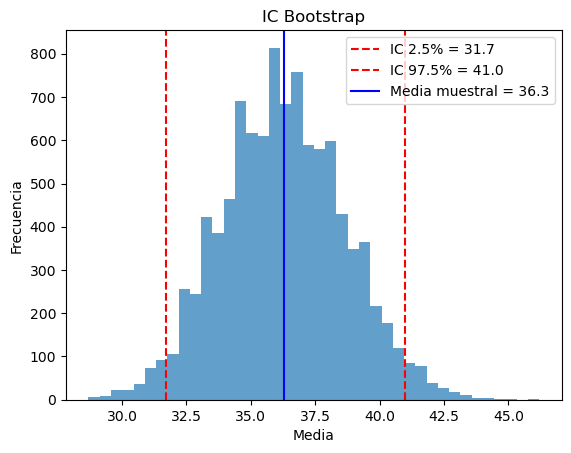

In [16]:
plt.hist(medias_bootstrap, bins=40,  alpha=0.7)

# Intervalo bootstrap
plt.axvline(ic_inf, color='red', linestyle='--', label=f'IC 2.5% = {ic_inf:.1f}')
plt.axvline(ic_sup, color='red', linestyle='--', label=f'IC 97.5% = {ic_sup:.1f}')


# Media muestral
plt.axvline(media_muestral, color='blue', linestyle='-', label=f'Media muestral = {media_muestral:.1f}')

plt.title("IC Bootstrap")
plt.xlabel("Media")
plt.ylabel("Frecuencia")
plt.legend()
plt.show()